In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [2]:
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])  # 读取原始数据
type(df)

pandas.core.frame.DataFrame

In [3]:
# 设置筛选条件
store_filter = df['Store ID'] == 'S001'       # 筛选门店
product_filter = df['Product ID'] == 'P0001'  # 筛选商品
date_filter = (df['Date'] >= '2022-01-01') & (df['Date'] <= '2023-12-31')  # 筛选日期范围

In [4]:
ts = df[store_filter & product_filter & date_filter].set_index("Date")['Units Sold']
type(ts)

pandas.core.series.Series

In [6]:
ts.to_csv('S001P0001Units_Sold.csv')  # 保存S001商店、P0001商品，2022年到2023年的日销量数据

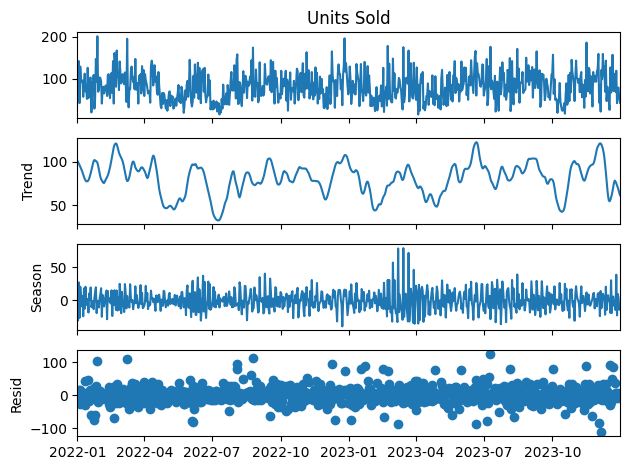

In [37]:
stl = STL(ts, period=7, robust=True)
res = stl.fit()
res.plot()
plt.show()

In [43]:
stl.config

{'period': 7,
 'seasonal': 7,
 'seasonal_deg': 1,
 'seasonal_jump': 1,
 'trend': 15,
 'trend_deg': 1,
 'trend_jump': 1,
 'low_pass': 9,
 'low_pass_deg': 1,
 'low_pass_jump': 1,
 'robust': True}

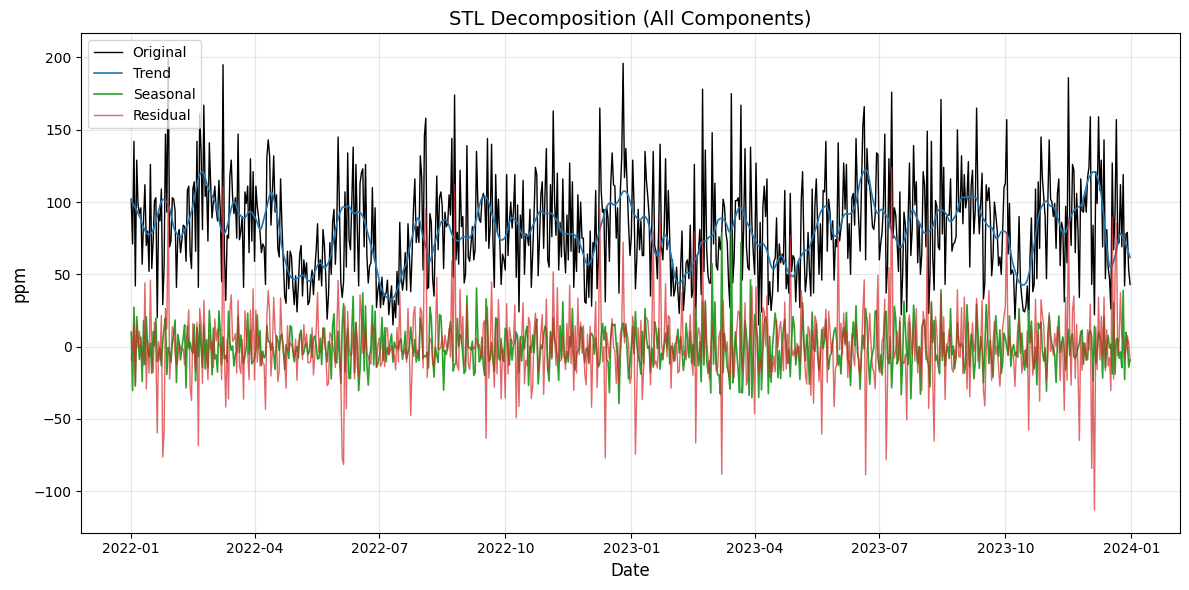

Seasonal Strength: 0.24
Trend Strength: 0.30
Residual Strength: 0.57


In [36]:
stl = STL(ts, period=7, seasonal=7, trend=15, robust=True)
result = stl.fit()

# 3) 绘制一张图：叠加原始序列、趋势、季节和残差
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, color='black', label='Original', linewidth=1)
plt.plot(result.trend.index, result.trend.values, color='tab:blue', label='Trend', linewidth=1.2)
plt.plot(result.seasonal.index, result.seasonal.values, color='tab:green', label='Seasonal', linewidth=1.2)
plt.plot(result.resid.index, result.resid.values, color='tab:red', label='Residual', linewidth=1.0, alpha=0.7)

plt.title('STL Decomposition (All Components)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('ppm', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

var_resid = np.var(result.resid)
var_seasonal_resid = np.var(result.seasonal + result.resid)
season_strength = max(0, 1 - var_resid / var_seasonal_resid)
print(f"Seasonal Strength: {season_strength:.2f}")

# 趋势强度
var_trend_resid = np.var(result.trend + result.resid)
trend_strength = max(0, 1 - var_resid / var_trend_resid)
print(f"Trend Strength: {trend_strength:.2f}")

# 残差强度
var_total = np.var(result.trend + result.seasonal + result.resid)
resid_strength = var_resid / var_total
print(f"Residual Strength: {resid_strength:.2f}")

In [45]:
# -*- coding: utf-8 -*-
# 说明：对日/周/月/季四种采样版本，分别跑指定周期的 STL 分解强度
# 约定：图表标题和坐标轴为英文；代码注释为中文

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL

# 假设 ts 是日频零售交易量序列，索引为 DatetimeIndex
# 例如：ts = df['sales']

# 1) 生成四种采样版本
ts_daily = ts.asfreq('D')                   # 日频
ts_weekly = ts.resample('W').sum()          # 周频
ts_monthly = ts.resample('ME').sum()         # 月频
ts_quarterly = ts.resample('QE').sum()       # 季频

# 2) 定义强度计算函数
def stl_strength(ts, period, freq_label):
    stl = STL(ts, period=period, robust=True)
    result = stl.fit()
    var_resid = np.var(result.resid)
    var_seasonal_resid = np.var(result.seasonal + result.resid)
    var_trend_resid = np.var(result.trend + result.resid)
    var_total = np.var(result.trend + result.seasonal + result.resid)

    season_strength = max(0, 1 - var_resid / var_seasonal_resid)
    trend_strength = max(0, 1 - var_resid / var_trend_resid)
    resid_strength = var_resid / var_total

    return {
        "freq": freq_label,
        "period": period,
        "season_strength": season_strength,
        "trend_strength": trend_strength,
        "resid_strength": resid_strength
    }

# 3) 批量运行
results = []

# Daily: 7, 30, 90, 365
for p in [7, 30, 90, 365]:
    results.append(stl_strength(ts_daily, p, "Daily"))

# Weekly: 4, 13, 52
for p in [4, 13, 52]:
    results.append(stl_strength(ts_weekly, p, "Weekly"))

# Monthly: 3, 12
for p in [3, 12]:
    results.append(stl_strength(ts_monthly, p, "Monthly"))

# Quarterly: 4
results.append(stl_strength(ts_quarterly, 4, "Quarterly"))

# 4) 输出结果表
df_compare = pd.DataFrame(results)
print(df_compare.round(2))


        freq  period  season_strength  trend_strength  resid_strength
0      Daily       7             0.24            0.30            0.57
1      Daily      30             0.22            0.17            0.67
2      Daily      90             0.25            0.08            0.72
3      Daily     365             0.92            0.00            0.08
4     Weekly       4             0.00            0.40            0.61
5     Weekly      13             0.27            0.16            0.67
6     Weekly      52             1.00            0.91            0.00
7    Monthly       3             0.45            0.44            0.42
8    Monthly      12             0.69            0.06            0.31
9  Quarterly       4             1.00            1.00            0.00


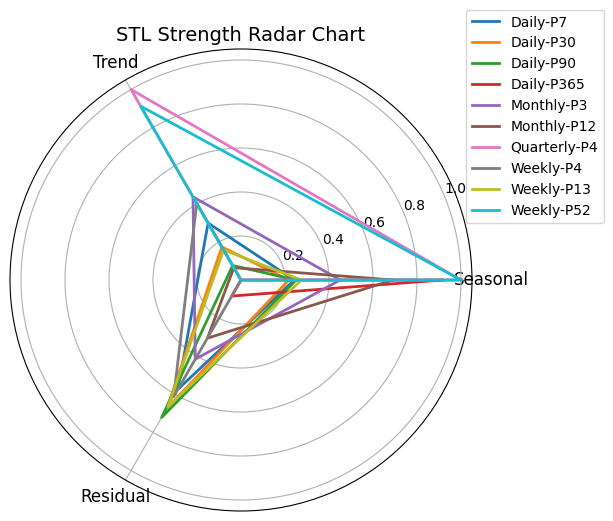

In [26]:
# -*- coding: utf-8 -*-
# 说明：绘制雷达图比较不同采样频率/周期下的强度
# 约定：图表标题和坐标轴为英文；代码注释为中文

import matplotlib.pyplot as plt
import numpy as np

# 假设 df_compare 已经包含以下列：
# ['freq', 'period', 'season_strength', 'trend_strength', 'resid_strength']

def plot_radar(df, group_col="freq"):
    labels = ["Seasonal", "Trend", "Residual"]
    num_vars = len(labels)

    # 角度设置
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # 闭合

    plt.figure(figsize=(8, 6))

    # 按 group_col 分组绘制
    for name, group in df.groupby(group_col):
        for _, row in group.iterrows():
            values = [row["season_strength"], row["trend_strength"], row["resid_strength"]]
            values += values[:1]
            plt.polar(angles, values, label=f'{name}-P{row["period"]}', linewidth=2)

    plt.xticks(angles[:-1], labels, fontsize=12)
    plt.title("STL Strength Radar Chart", fontsize=14)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()

# 调用函数
plot_radar(df_compare)

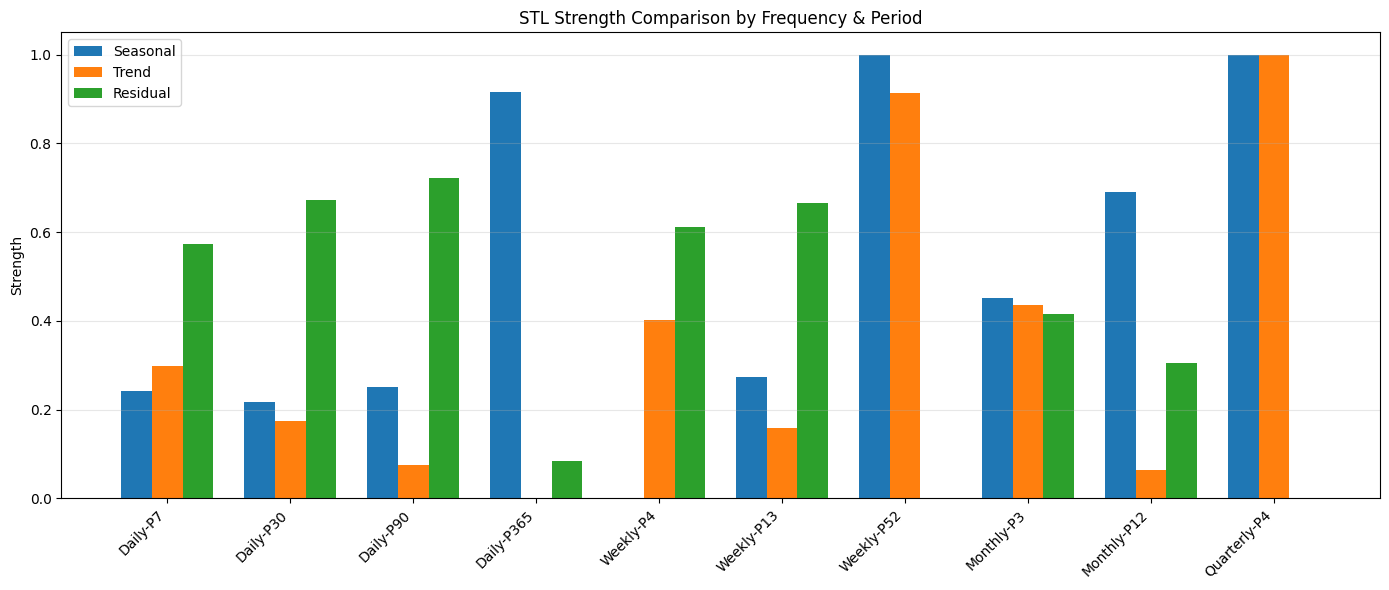

In [27]:
# -*- coding: utf-8 -*-
# 说明：绘制分组柱状图比较不同采样频率/周期下的强度
# 约定：图表标题和坐标轴为英文；代码注释为中文

import matplotlib.pyplot as plt
import numpy as np

# 假设 df_compare 已经包含以下列：
# ['freq', 'period', 'season_strength', 'trend_strength', 'resid_strength']

def plot_grouped_bars(df):
    metrics = ["season_strength", "trend_strength", "resid_strength"]
    labels = ["Seasonal", "Trend", "Residual"]

    # 每个组合的标签：freq + period
    groups = df.apply(lambda row: f"{row['freq']}-P{row['period']}", axis=1)

    x = np.arange(len(groups))  # X 轴位置
    width = 0.25                # 每组柱子的宽度

    fig, ax = plt.subplots(figsize=(14, 6))

    # 绘制三组柱子
    for i, metric in enumerate(metrics):
        ax.bar(x + i*width, df[metric], width, label=labels[i])

    # 设置 X 轴标签
    ax.set_xticks(x + width)
    ax.set_xticklabels(groups, rotation=45, ha="right")

    ax.set_ylabel("Strength")
    ax.set_title("STL Strength Comparison by Frequency & Period")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# 调用函数
plot_grouped_bars(df_compare)

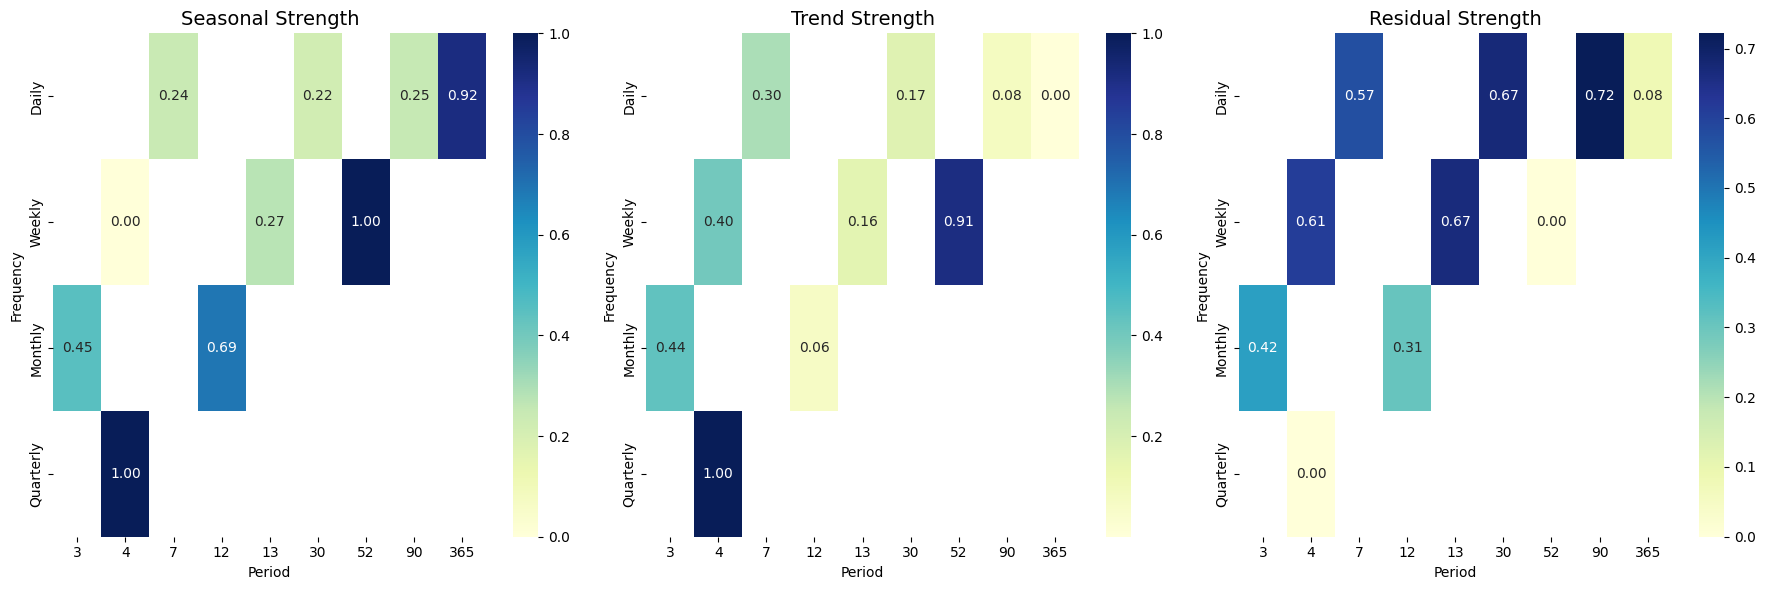

In [29]:
# -*- coding: utf-8 -*-
# 说明：绘制热力图比较不同采样频率/周期下的强度
# 约定：图表标题和坐标轴为英文；代码注释为中文

import seaborn as sns
import matplotlib.pyplot as plt

# 假设 df_compare 已经包含以下列：
# ['freq', 'period', 'season_strength', 'trend_strength', 'resid_strength']

def plot_heatmaps(df):
    metrics = ["season_strength", "trend_strength", "resid_strength"]
    labels = ["Seasonal Strength", "Trend Strength", "Residual Strength"]

    # 固定顺序排序
    freq_order = ["Daily", "Weekly", "Monthly", "Quarterly"]
    df["freq"] = pd.Categorical(df["freq"], categories=freq_order, ordered=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, metric in enumerate(metrics):
        pivot = df.pivot(index="freq", columns="period", values=metric)
        pivot = pivot.loc[freq_order]  # 按顺序排列
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], cbar=True)
        axes[i].set_title(labels[i], fontsize=14)
        axes[i].set_xlabel("Period")
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 调用函数
plot_heatmaps(df_compare)

## 残差诊断

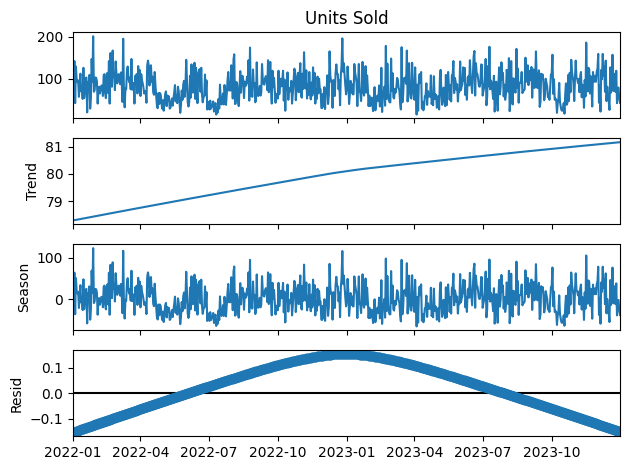

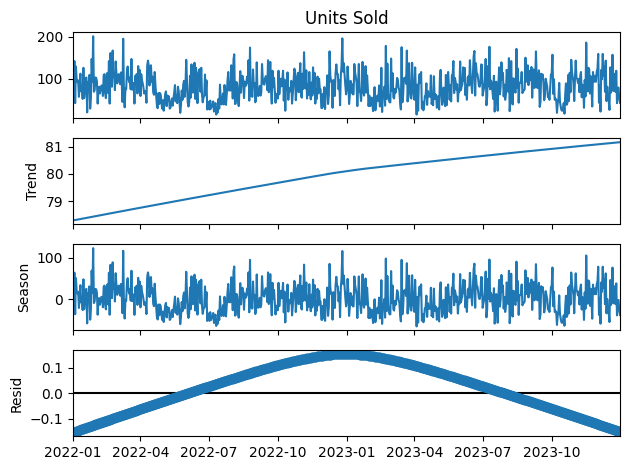

In [95]:
stl = STL(ts, period=360, robust=True)
res = stl.fit()
res.plot()

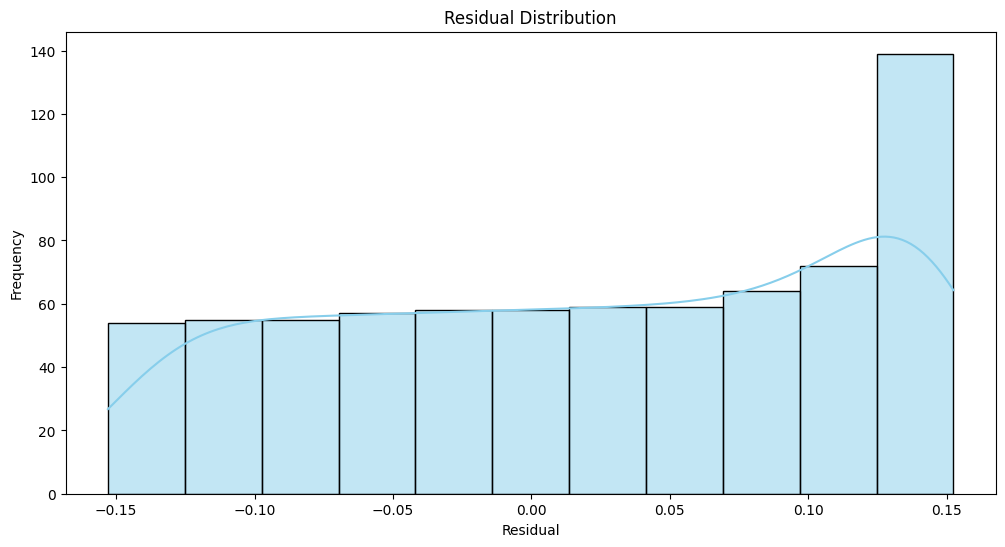

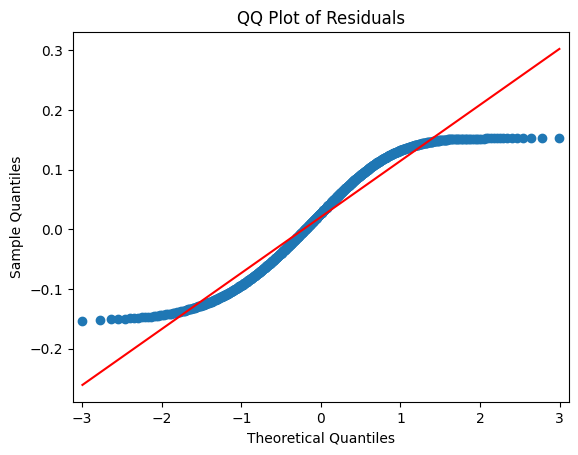

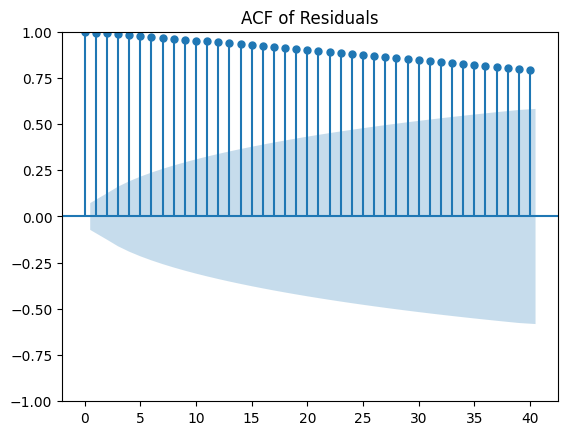

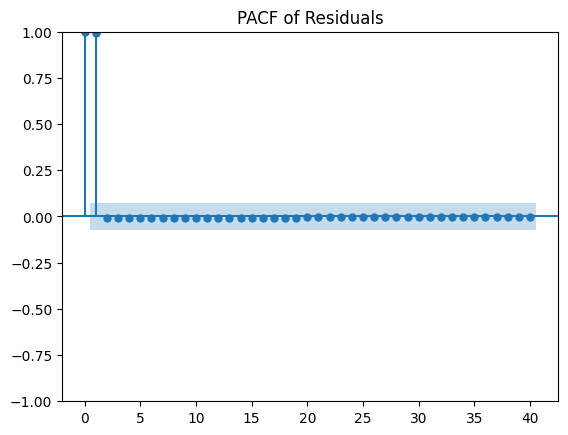

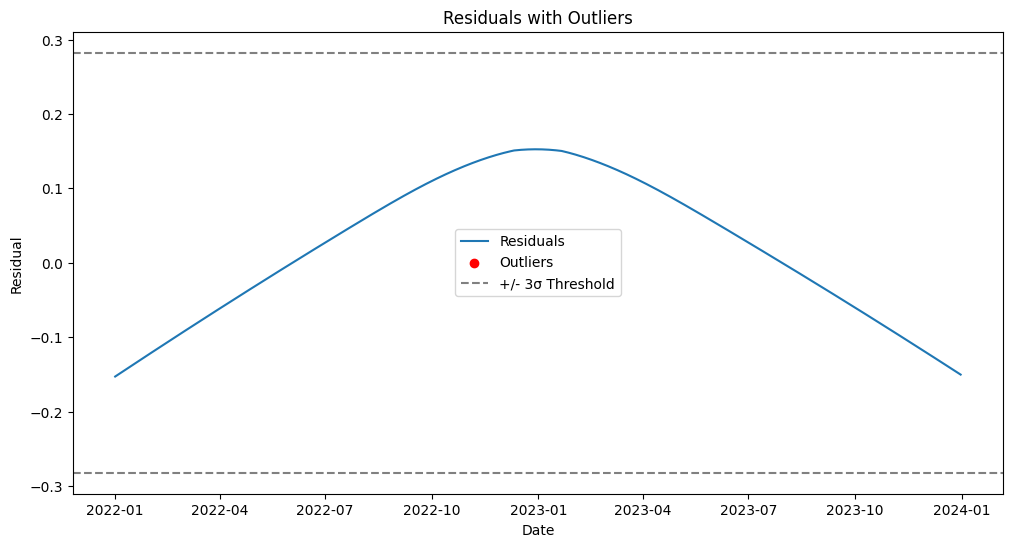

Outliers (Residuals > ±3σ):
Series([], Name: resid, dtype: float64)


In [97]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

resid = res.resid.dropna()

# 1. Residual distribution
plt.figure(figsize=(12,6))
sns.histplot(resid, kde=True, color="skyblue")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# 2. QQ plot
sm.qqplot(resid, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

# 3. ACF / PACF
plot_acf(resid, lags=40)
plt.title("ACF of Residuals")
plt.show()

plot_pacf(resid, lags=40, method="ywm")
plt.title("PACF of Residuals")
plt.show()

# 4. Outlier detection
threshold = 3 * resid.std()
anomalies = resid[np.abs(resid) > threshold]

plt.figure(figsize=(12,6))
plt.plot(resid, label="Residuals")
plt.scatter(anomalies.index, anomalies.values, color="red", label="Outliers")
plt.axhline(threshold, color="gray", linestyle="--", label="+/- 3σ Threshold")
plt.axhline(-threshold, color="gray", linestyle="--")
plt.title("Residuals with Outliers")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

print("Outliers (Residuals > ±3σ):")
print(anomalies)

# 多重季节分解 MSTL

In [ ]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(ts, periods=[7, 30])
results = mstl.fit()
results.plot()

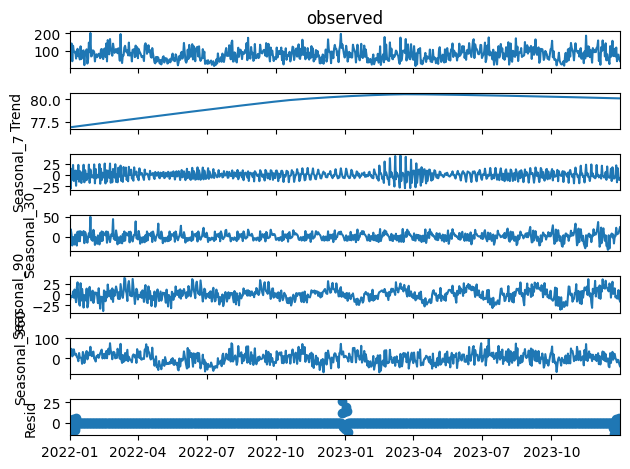

季节性/趋势强度对比：
seasonal_7: 0.96
seasonal_30: 0.97
seasonal_90: 0.98
seasonal_360: 0.99
trend_strength: 0.24
resid_strength: 0.00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

# 假设 ts 是一个 pandas Series，index 是 DatetimeIndex
# 例如：
# ts = pd.Series(data, index=pd.date_range("2020-01-01", periods=len(data), freq="D"))

# 1. 多周期分解
mstl = MSTL(ts, periods=[7, 30, 90, 360])   # 周效应 + 月效应 + 季度效应 + 年度效应
res = mstl.fit()

# 2. 绘制分解结果
res.plot()
plt.show()

# 3. 计算季节性/趋势/残差强度
def calc_strength(component, resid):
    var_c = component.var()
    var_r = resid.var()
    return max(0, 1 - var_r / (var_c + var_r))

strengths = {}
for col in res.seasonal.columns:
    strengths[col] = calc_strength(res.seasonal[col], res.resid)

strengths["trend_strength"] = calc_strength(res.trend, res.resid)
strengths["resid_strength"] = res.resid.var() / ts.var()

# 4. 打印结果
print("季节性/趋势强度对比：")
for k, v in strengths.items():
    print(f"{k}: {v:.2f}")

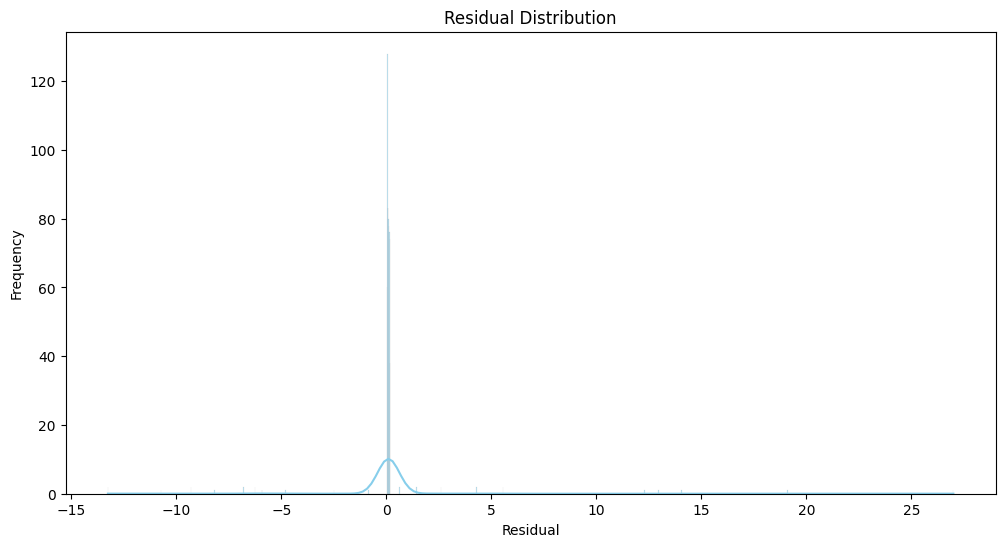

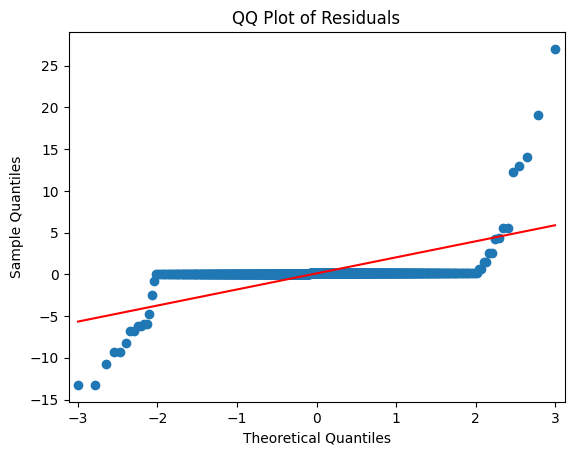

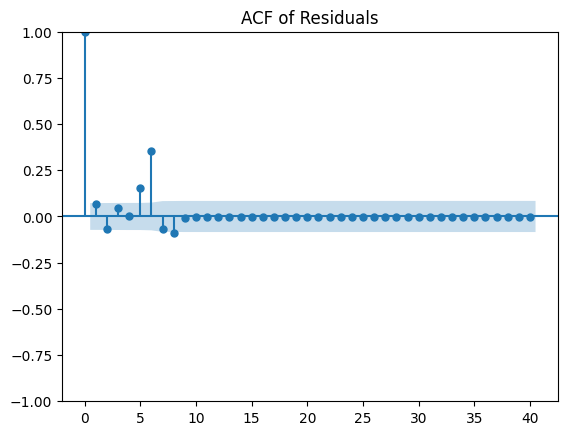

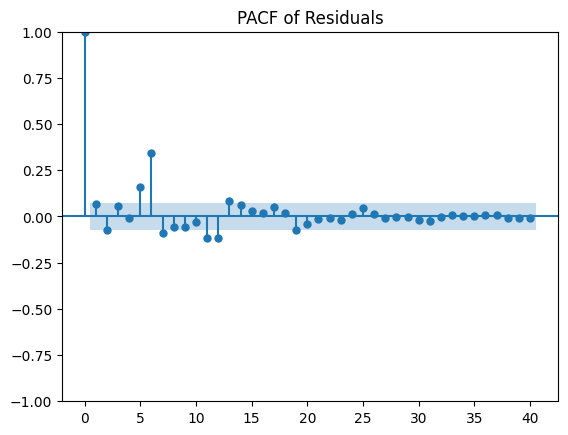

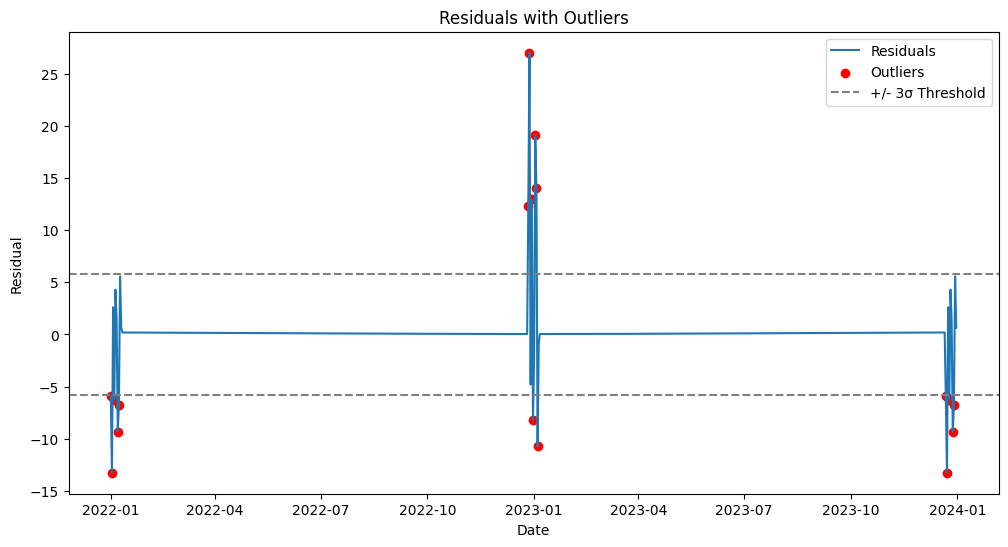

Outliers (Residuals > ±3σ):
Date
2022-01-01    -5.916041
2022-01-02   -13.250251
2022-01-04    -6.248181
2022-01-07    -9.310824
2022-01-08    -6.798255
2022-12-27    12.296898
2022-12-28    27.004459
2022-12-30    12.959832
2022-12-31    -8.176056
2023-01-02    19.098779
2023-01-03    14.058834
2023-01-04   -10.732549
2023-12-22    -5.919707
2023-12-23   -13.252873
2023-12-25    -6.248716
2023-12-28    -9.308228
2023-12-29    -6.794615
Name: resid, dtype: float64


In [99]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

resid = res.resid.dropna()

# 1. Residual distribution
plt.figure(figsize=(12,6))
sns.histplot(resid, kde=True, color="skyblue")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# 2. QQ plot
sm.qqplot(resid, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

# 3. ACF / PACF
plot_acf(resid, lags=40)
plt.title("ACF of Residuals")
plt.show()

plot_pacf(resid, lags=40, method="ywm")
plt.title("PACF of Residuals")
plt.show()

# 4. Outlier detection
threshold = 3 * resid.std()
anomalies = resid[np.abs(resid) > threshold]

plt.figure(figsize=(12,6))
plt.plot(resid, label="Residuals")
plt.scatter(anomalies.index, anomalies.values, color="red", label="Outliers")
plt.axhline(threshold, color="gray", linestyle="--", label="+/- 3σ Threshold")
plt.axhline(-threshold, color="gray", linestyle="--")
plt.title("Residuals with Outliers")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

print("Outliers (Residuals > ±3σ):")
print(anomalies)

=== Ljung–Box 白噪声检验 ===
     lb_stat  lb_pvalue
10  4.609475   0.915695
残差近似白噪声，MSTL 分解充分。


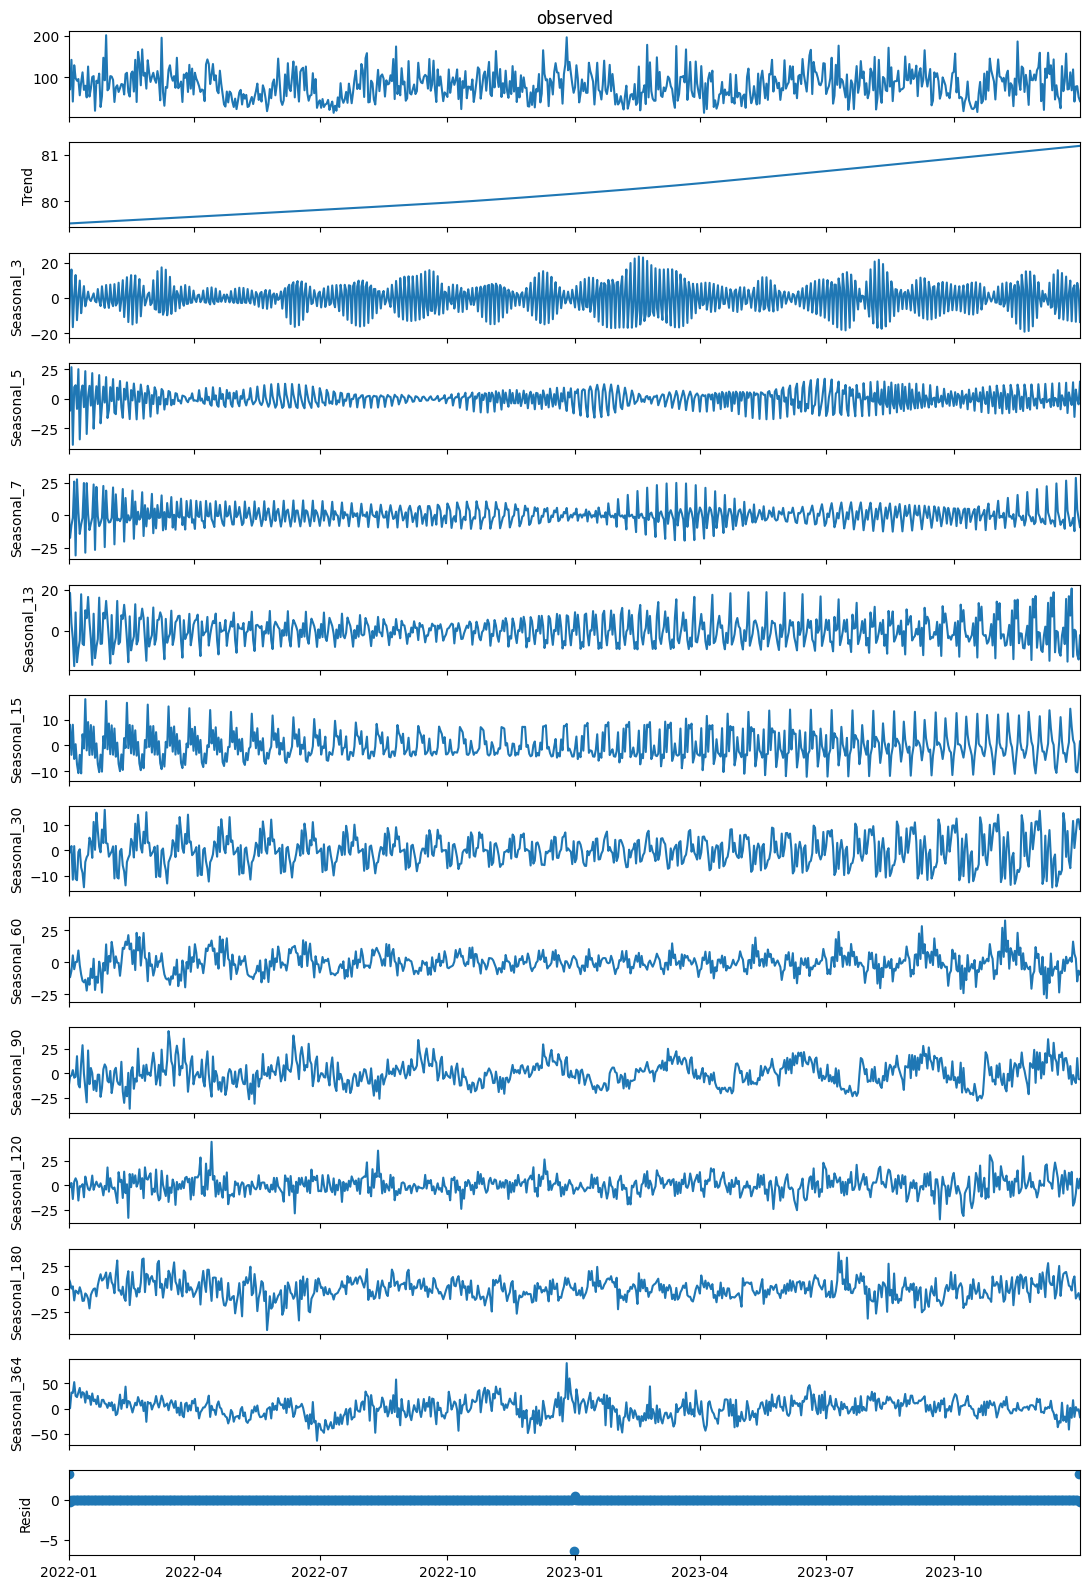

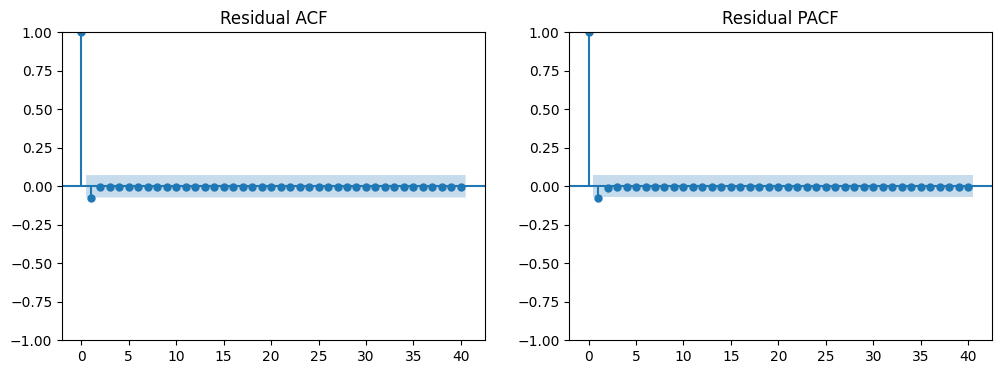


=== 异常点检测（|resid| > 3σ） ===
Date
2022-01-01    3.217324
2022-12-31   -6.485025
2023-12-30    3.217379
Name: resid, dtype: float64


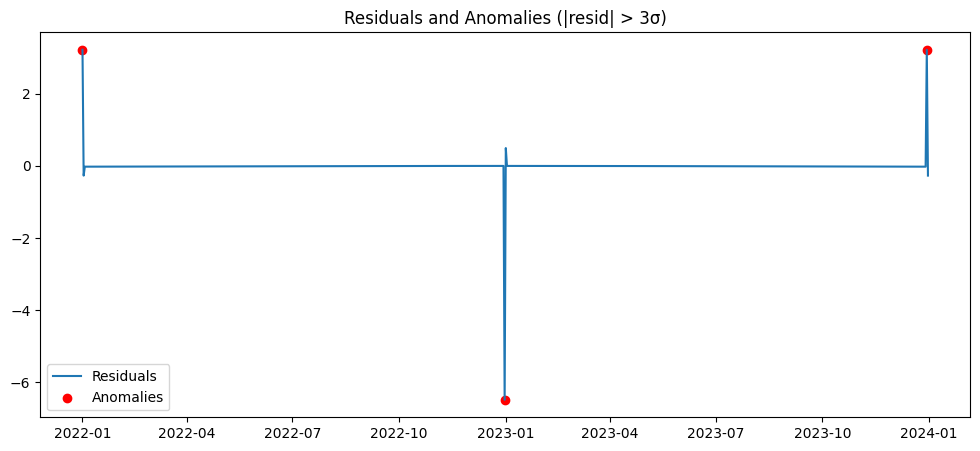

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

mstl = MSTL(ts, periods=[3, 5, 7, 13, 15, 30, 60, 90, 120, 180, 364])
result = mstl.fit()

# === 3️⃣ 输出主要结果 ===
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# === 4️⃣ 白噪声检验（Ljung–Box） ===
lb_result = acorr_ljungbox(residual, lags=[10], return_df=True)
print("=== Ljung–Box 白噪声检验 ===")
print(lb_result)

if lb_result['lb_pvalue'].values[0] < 0.05:
    print("残差不是白噪声，说明仍有结构性模式。")
else:
    print("残差近似白噪声，MSTL 分解充分。")

# === 5️⃣ 绘制分解结果 ===
fig = result.plot()
fig.set_size_inches(11, 16)
plt.tight_layout()
plt.show()

# === 6️⃣ 绘制残差自相关图 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residual, lags=40, ax=axes[0])
plot_pacf(residual, lags=40, ax=axes[1])
axes[0].set_title("Residual ACF")
axes[1].set_title("Residual PACF")
plt.show()

# === 7️⃣ 检测残差异常点 ===
resid_std = residual.std()
threshold = 3 * resid_std
anomalies = residual[(abs(residual) > threshold)]

print("\n=== 异常点检测（|resid| > 3σ） ===")
print(anomalies)

# === 8️⃣ 绘制残差与异常点 ===
plt.figure(figsize=(12, 5))
plt.plot(residual, label='Residuals')
plt.scatter(anomalies.index, anomalies, color='red', label='Anomalies')
plt.title("Residuals and Anomalies (|resid| > 3σ)")
plt.legend()
plt.show()

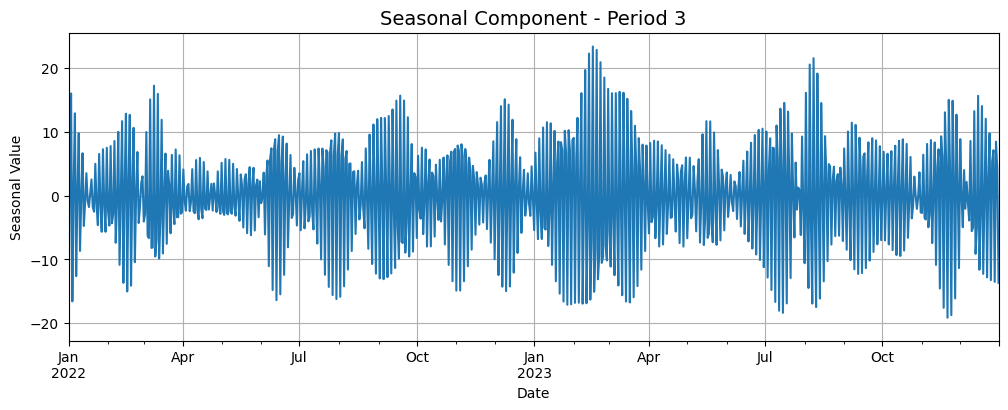

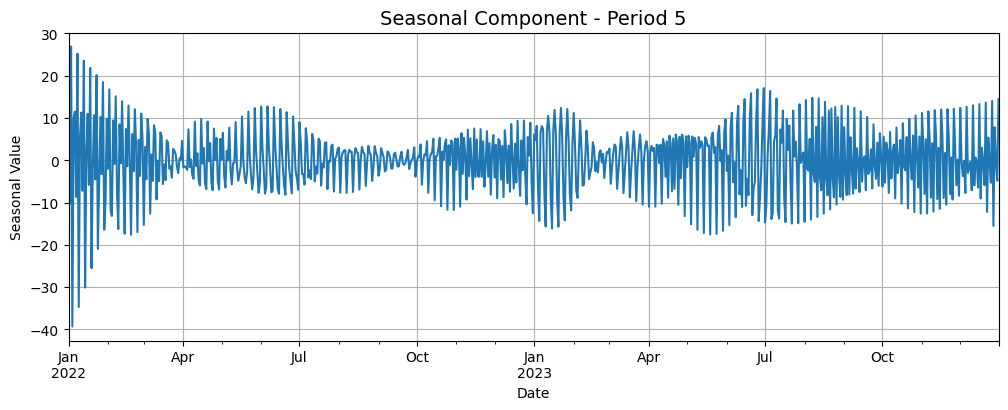

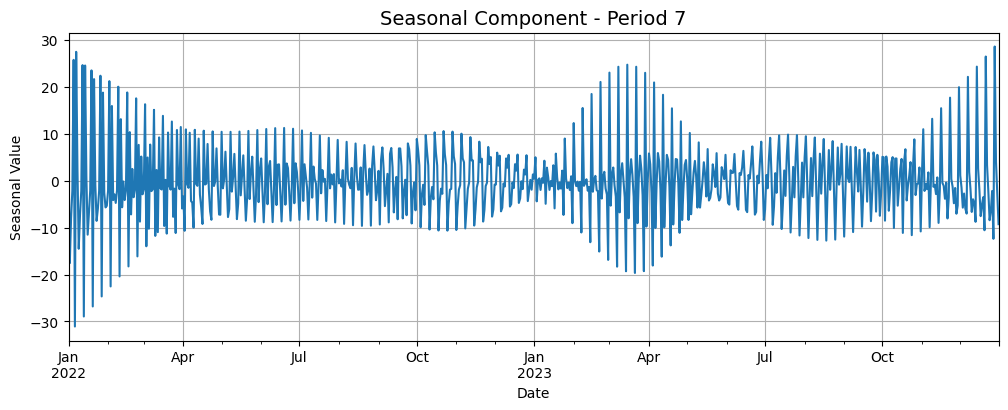

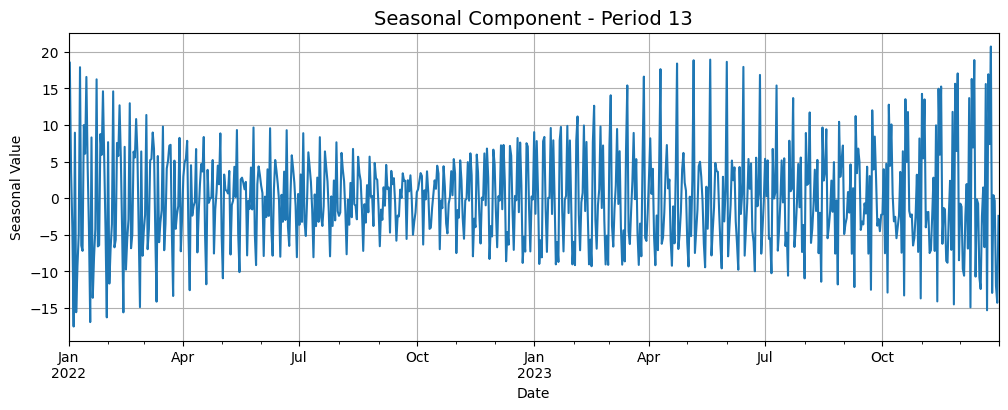

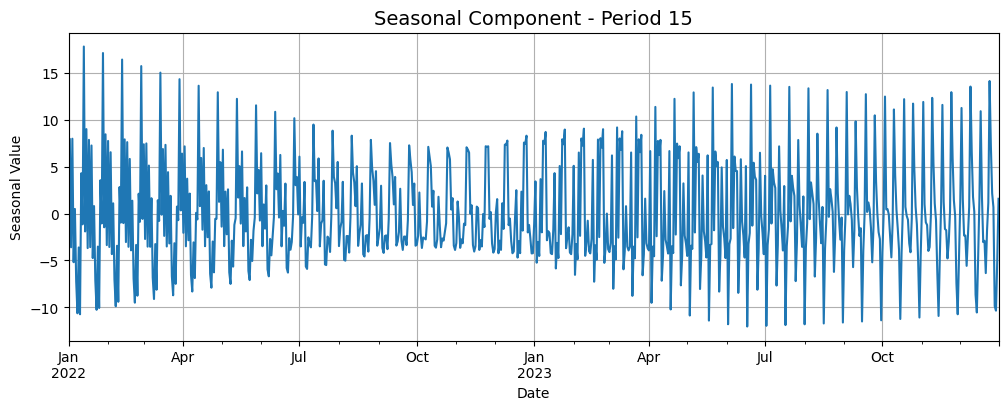

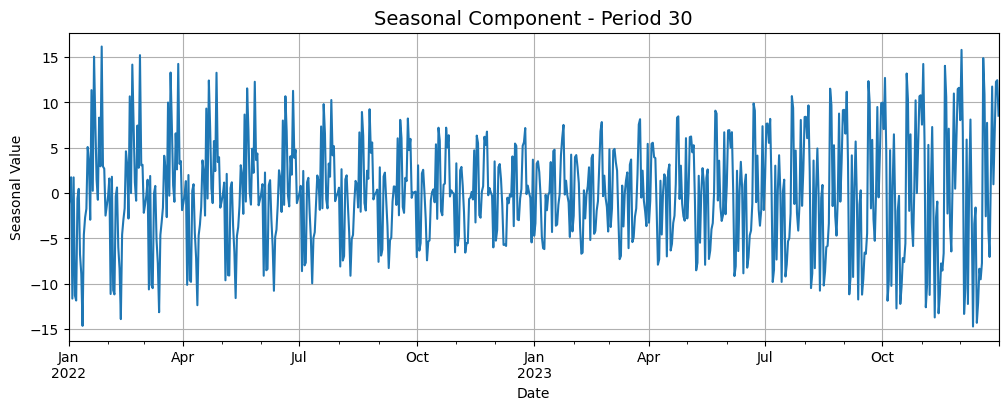

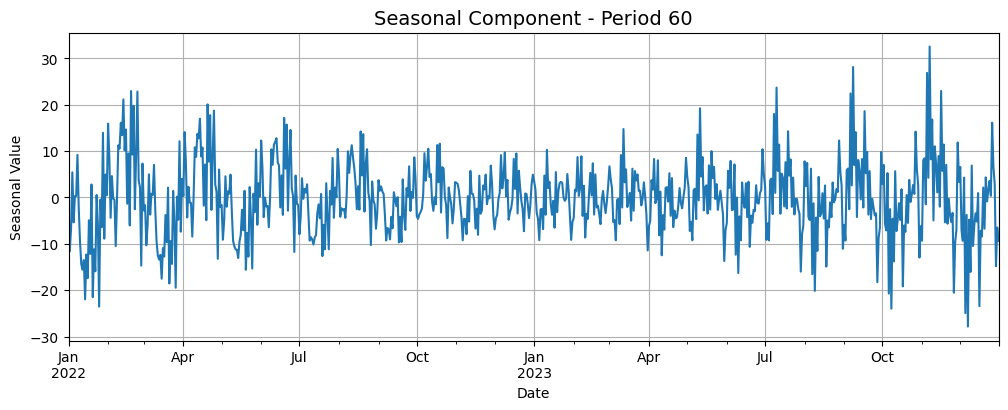

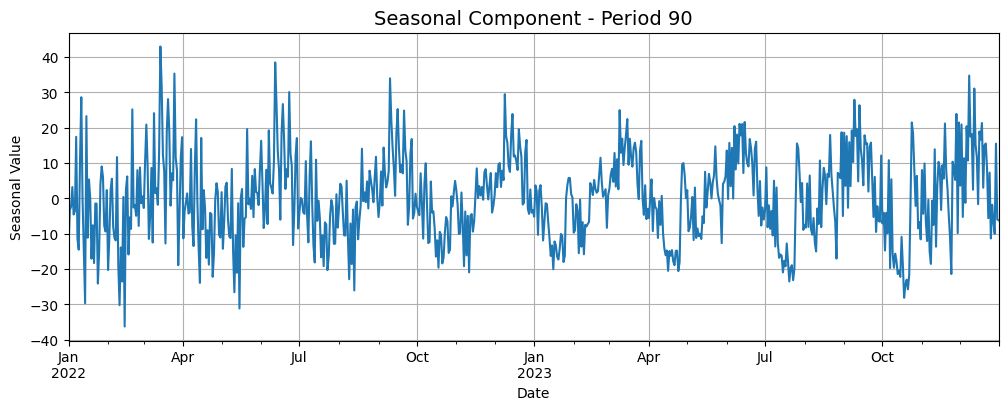

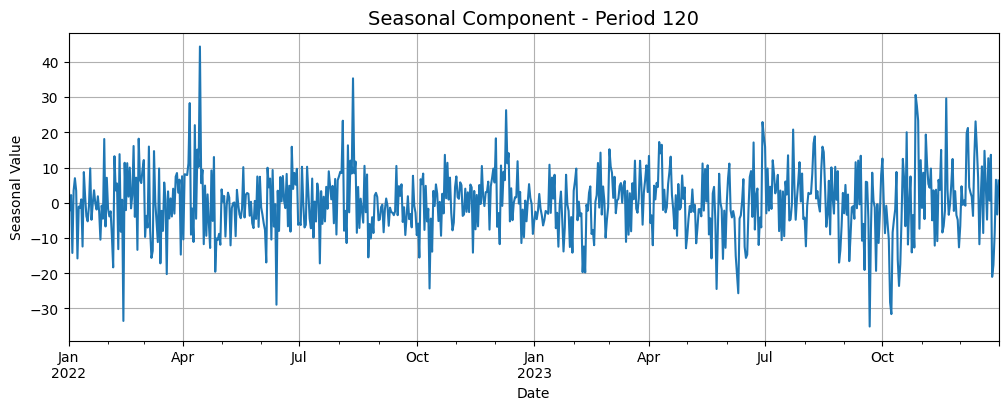

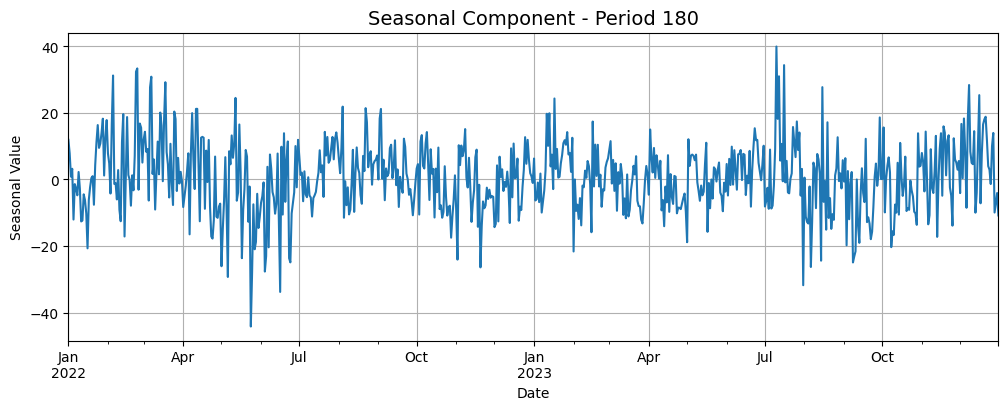

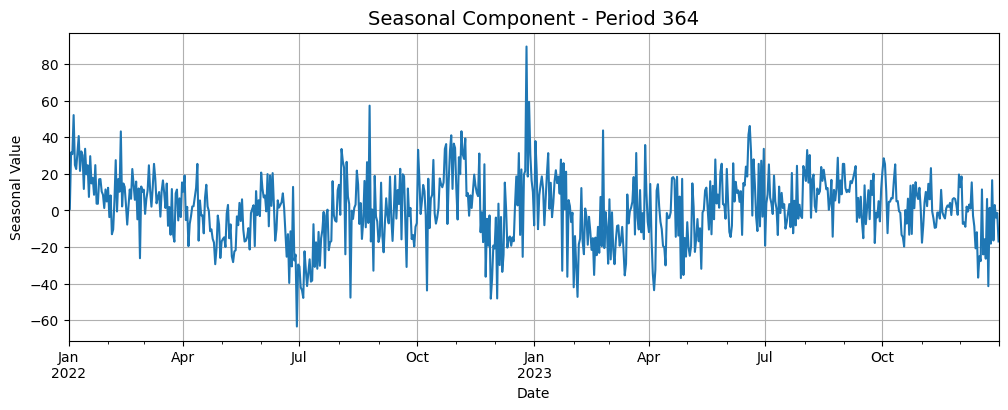

In [120]:
import matplotlib.pyplot as plt

seasonal_df = result.seasonal

# 遍历每个季节性成分
for col in seasonal_df.columns:
    plt.figure(figsize=(12,4))
    seasonal_df[col].plot()
    period = col.split('_')[-1]
    plt.title(f"Seasonal Component - Period {period}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Seasonal Value")
    plt.grid(True)
    plt.show()

In [12]:
ts = ts.asfreq('D')
ts

Date
2022-01-01    102
2022-01-02     71
2022-01-03    142
2022-01-04     42
2022-01-05    129
             ... 
2023-12-27     42
2023-12-28     78
2023-12-29     79
2023-12-30     53
2023-12-31     43
Freq: D, Name: Units Sold, Length: 730, dtype: int64

In [13]:
deseasonalized = ts - result.seasonal.sum(axis=1)

In [14]:
deseasonalized

Date
2022-01-01    82.732559
2022-01-02    79.246435
2022-01-03    79.495488
2022-01-04    79.497151
2022-01-05    79.498816
                ...    
2023-12-27    81.157546
2023-12-28    81.160481
2023-12-29    81.163417
2023-12-30    84.406750
2023-12-31    80.921900
Freq: D, Length: 730, dtype: float64

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(deseasonalized, order=(1, 1, 1))
fit = model.fit()
print(fit.summary())

In [ ]:
# import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 假设 ts 是日频时间序列
# 设置频率，避免 Warning
ts = ts.asfreq('D')

# SARIMA 模型：这里假设有年度季节性 (s=365)
model = SARIMAX(ts,
                order=(1,1,1),          # 非季节部分
                seasonal_order=(1,1,1,364),  # 季节部分
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

print(result.summary())

# 残差诊断
result.plot_diagnostics(figsize=(12,8))
plt.show()

E:\Program Files\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


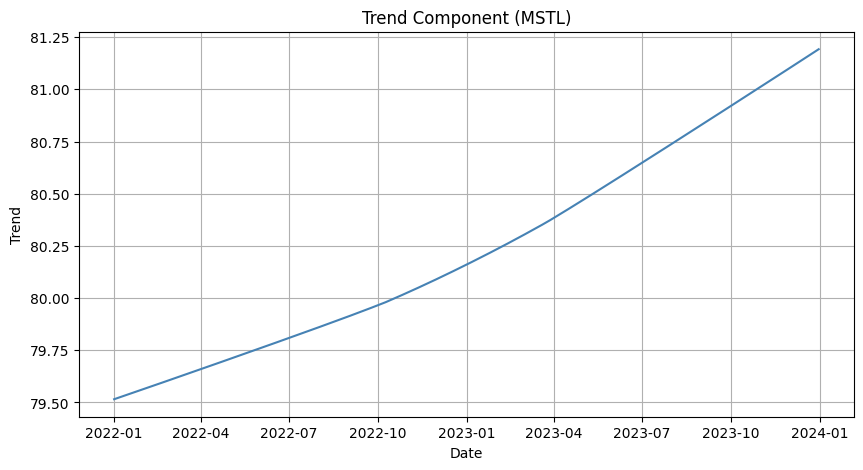

In [8]:
plt.figure(figsize=(10,5))
plt.plot(result.trend, color='steelblue')
plt.title('Trend Component (MSTL)')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.grid(True)
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

t = np.arange(len(result.trend)).reshape(-1, 1)
model = LinearRegression().fit(t, result.trend)
slope = model.coef_[0]
print(f"趋势斜率: {slope:.4f}")

趋势斜率: 0.0023


In [8]:
import numpy as np

trend_strength = 1 - np.var(res.resid) / np.var(res.trend + res.resid)
print(f"趋势强度指数: {trend_strength:.3f}")


趋势强度指数: 0.273


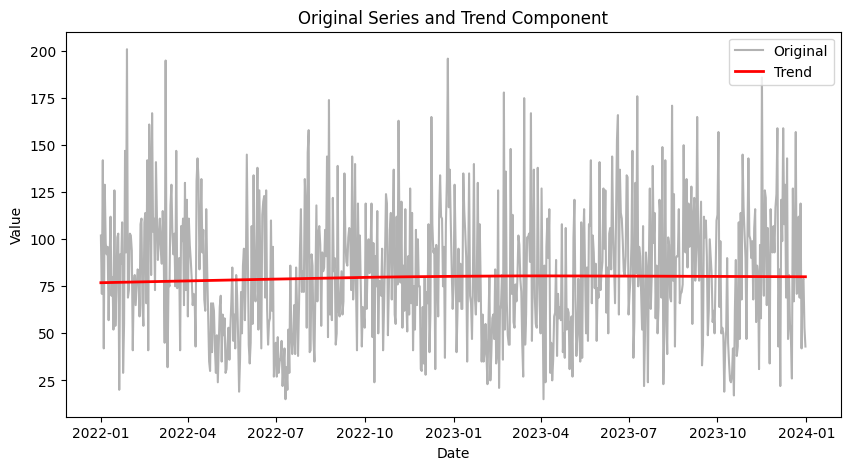

In [9]:
plt.figure(figsize=(10,5))
plt.plot(ts, label='Original', color='gray', alpha=0.6)
plt.plot(res.trend, label='Trend', color='red', linewidth=2)
plt.title('Original Series and Trend Component')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()